# Duel contre les prévisions de RTE

Objectf : comparer notre modèle v2 aux prévisions officielles J-1 de RTE, à métrique et terrain égaux

Avant de calculer, mon pari : je parie que la MAE des prévisions J-1 de RTE sur 2024 est d'environ 600 MW, soit à peu près 1% de la consommation moyenne journalière, ce qui correspond à la précision que RTE revendique sur ses prévisions de la veille. Autrement dit, je parie que les pros sont environ deux fois meilleurs que notre modèle v2 (1126 MW), ce qui serait un écart logique vu leurs moyens : prévisions météo professionnelles par heure et par région, historique de plusieurs décennies, et des équipes dédiées à plein temps.

## Préparation des données

In [1]:
import pandas as pd

In [2]:
eco2mix=pd.read_csv("../data/eco2mix_2023_2024.csv", sep=";")
eco2mix=eco2mix.dropna(subset=['consommation'])
eco2mix['date_heure']=pd.to_datetime(eco2mix['date_heure'])
eco2mix["date"] = eco2mix["date_heure"].dt.floor("D")
conso_jour = eco2mix.groupby('date')[['consommation', 'prevision_j1']].mean().reset_index()
df_jour = eco2mix.groupby('date')[['consommation', 'prevision_j1']].mean().reset_index()

In [3]:
df_jour.head()

,date,consommation,prevision_j1
0,2023-01-01 00:00:00+00:00,43010.500000,41389.583333
1,2023-01-02 00:00:00+00:00,50014.312500,50360.416667
2,2023-01-03 00:00:00+00:00,56098.625000,56625.000000
3,2023-01-04 00:00:00+00:00,56889.291667,57247.916667
4,2023-01-05 00:00:00+00:00,55379.729167,55797.916667


In [4]:
len(df_jour)

731

In [5]:
df_jour.describe()

,consommation,prevision_j1
count,731.000000,731.000000
mean,49912.662736,48774.058516
std,9118.759818,9087.103638
min,35818.604167,33033.333333
25%,43769.427083,42758.333333
50%,46661.437500,45722.916667
75%,56689.489583,54980.208333
max,78160.708333,77977.083333


## Découverte d'un biais de mesure

In [6]:
df_jour["ecart"] = df_jour["consommation"] - df_jour["prevision_j1"]

In [7]:
df_jour["ecart"].describe()

count     731.000000
mean     1138.604220
std       888.488482
min     -1754.958333
25%       564.739583
50%      1070.187500
75%      1649.343750
max      4747.770833
Name: ecart, dtype: float64

<Axes: xlabel='date'>

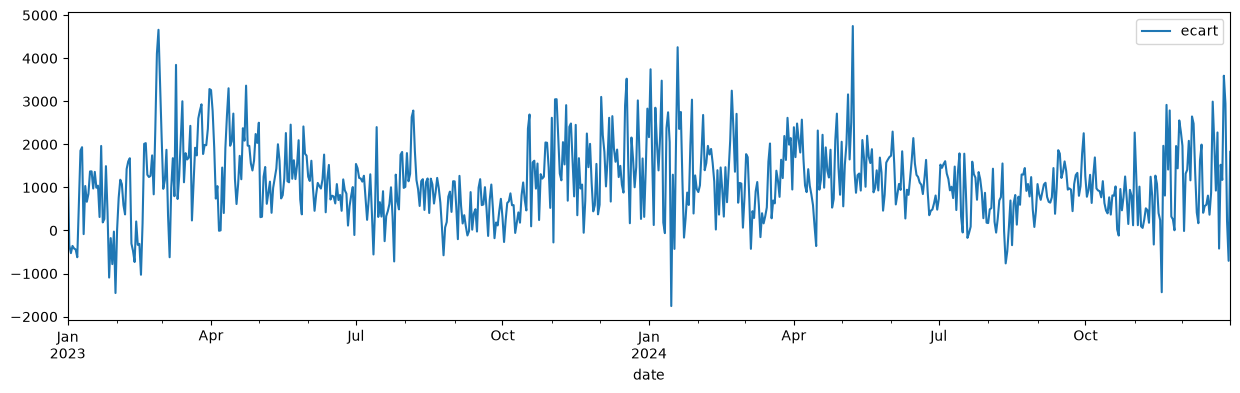

In [8]:
df_jour.plot(x="date", y="ecart", figsize=(15,4))

In [9]:
(df_jour["ecart"] < 0).mean()

np.float64(0.07660738714090287)

<Axes: ylabel='Frequency'>

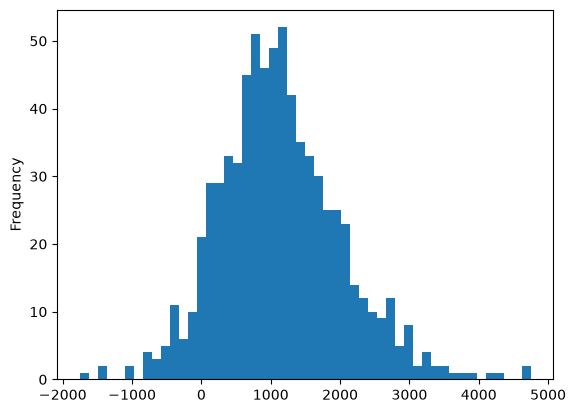

In [10]:
df_jour["ecart"].plot(kind="hist", bins=50)

Avant de calculer la MAE de RTE, on remarque un problème dans les données : leurs prévisions sont en moyenne 1139 MW en dessous de la consommation réalisée, et ce décalage est systématique. En effet, la médiane de l'écart est à +1070 MW, seulement 7,7% des jours ont un écart négatif (alors qu'un prévisionniste non biaisé serait autour de 50%), et l'histogramme de l'écart montre une cloche centrée sur +1100 MW au lieu de 0.

Un biais pareil chez des professionnels ne peut pas être une erreur de modèle (il suffirait de rajouter 1100 MW à toutes leurs prévisions pour le corriger), on peut donc expliquer cela par une différence de mesure : nos données sont les valeurs "consolidées et définitives", c'est-à-dire la consommation révisée et corrigée des semaines après coup, alors que la prévision de RTE visait la consommation telle que mesurée le jour même. Autrement dit, on ne compare pas leur prévision au bon thermomètre, et notre propre modèle a un avantage déloyal vu qu'il a été entraîné directement sur les données définitives.

Pour un duel équitable, on corrige donc ce biais de mesure : on l'estime sur 2023 uniquement (même discipline que le split train/test, on n'utilise jamais 2024 pour se régler), on l'ajoute aux prévisions de RTE, et on calcule leur MAE sur 2024 avec cette correction. On donnera quand même la MAE brute à titre indicatif.

## Le duel corrigé

In [11]:
biais_2023=df_jour[df_jour['date'].dt.year==2023]['ecart'].mean()

In [12]:
df_jour["prevision_corrigee"] = df_jour["prevision_j1"] + biais_2023

In [13]:
df_2024=df_jour[df_jour['date'].dt.year==2024]

In [14]:
mae_brute = df_2024['ecart'].abs().mean()

In [15]:
mae_corrigee = (df_2024['consommation'] - df_2024['prevision_corrigee']).abs().mean()

In [16]:
print(f"MAE brute RTE : {round(mae_brute)} MW")
print(f"MAE corrigée RTE : {round(mae_corrigee)} MW")
print(f"Notre modèle v2 : 1126 MW")

MAE brute RTE : 1192 MW
MAE corrigée RTE : 647 MW
Notre modèle v2 : 1126 MW


<Axes: title={'center': 'MAE des prévisions journalières sur 2024 (MW)'}>

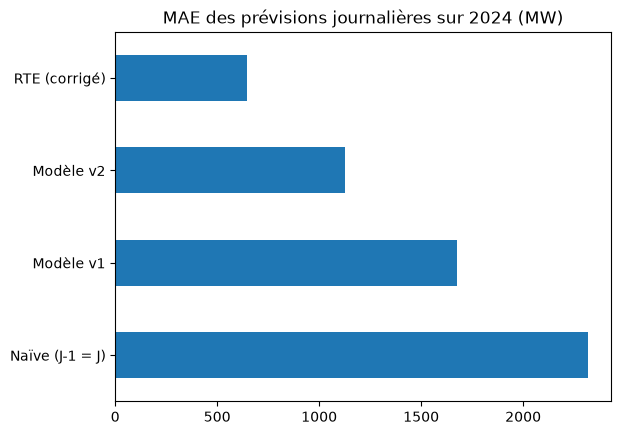

In [17]:
podium = pd.Series({
    "Naïve (J-1 = J)": 2316,
    "Modèle v1": 1675,
    "Modèle v2": 1126,
    "RTE (corrigé)": round(mae_corrigee),
})
podium.plot(kind="barh", title="MAE des prévisions journalières sur 2024 (MW)")

Le verdict du duel : la MAE corrigée de RTE est de 647 MW, contre 1126 MW pour notre modèle v2. Les pros restent devant, ils sont environ 1,7 fois meilleurs que nous, ce qui est logique vu leurs moyens : prévisions météo professionnelles par heure et par région, modèles non linéaires, et des équipes dédiées depuis des décennies, contre nos 5 features linéaires et notre température moyennée sur 8 villes. Être à un facteur 1,7 des meilleurs sur cet exercice avec un modèle aussi simple, on prend.

Au passage, mon pari (600 MW, basé sur le 1% de précision que RTE revendique) tombe à 47 MW du résultat, l'intuition se calibre.

Remarque importante : sans la correction du biais de mesure, on aurait conclu l'inverse ! La MAE brute de RTE (1192 MW) est supérieure à celle de notre modèle (1126 MW), on aurait donc pu prétendre "battre RTE", alors que cet écart venait du thermomètre (données consolidées vs temps réel) et pas de la qualité des prévisions. C'est la meilleure leçon de ce projet : les conclusions flatteuses sont celles qu'il faut vérifier deux fois.